In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from itertools import permutations
import warnings
from statsmodels.stats.stattools import jarque_bera
import statsmodels.stats.diagnostic as smd
warnings.filterwarnings('ignore')

# Output directory
OUTPUT_DIR = 'cannibalization_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
})

BRAND_COLOR = {
    'Richeese': '#378ADD',
    'Richoco':  '#D4537E',
    'Nextar':   '#1D9E75',
}
CAT_COLOR = {
    'Wafer':          '#378ADD',
    'Kue/Pie':        '#1D9E75',
    'Minuman':        '#D4537E',
    'Mi Instan':      '#BA7517',
    'Extruded Snack': '#534AB7',
    'Biskuit':        '#888780',
}

print('✅ Config selesai')
print(f'   Output dir : {OUTPUT_DIR} — exists: {os.path.exists(OUTPUT_DIR)}')


✅ Config selesai
   Output dir : cannibalization_output/ — exists: True


In [2]:
# Sesuaikan path ke lokasi file dataset v2 lo
DATA_PATH = 'cannibalization_output/simulated_dataset_v2.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = pd.to_datetime(df['Week'])

print(f'✅ Dataset loaded')
print(f'   Shape      : {df.shape}')
print(f'   Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'   Unique SKU : {df["SKU_ID"].nunique()}')
print(f'   Branches   : {sorted(df["Branch"].unique())}')
print(f'   Kolom      : {df.columns.tolist()}')
print(f'\nPromo distribution:')
print((df['Promo_Category'].value_counts(normalize=True)*100).round(1))
print(f'\nPromo days % per SKU:')
print((df.groupby('SKU_ID')['IsPromoDay'].mean()*100).round(1))


✅ Dataset loaded
   Shape      : (58480, 16)
   Date range : 2024-01-01 → 2025-12-31
   Unique SKU : 20
   Branches   : ['Bandung', 'Jakarta', 'Semarang', 'Surabaya']
   Kolom      : ['Date', 'Year', 'Month', 'Week', 'Branch', 'SKU_ID', 'SKU_Name', 'SKU_Category', 'Brand', 'NormalPrice', 'DiscountedPrice', 'DiscountPercentage', 'Promo_Category', 'IsPromoDay', 'Qty', 'Revenue']

Promo distribution:
Promo_Category
No Promo               90.3
Promo Seasonal High     4.6
Promo Normal            4.3
Promo Bundling          0.8
Name: proportion, dtype: float64

Promo days % per SKU:
SKU_ID
S001    14.5
S002    11.5
S003     9.8
S004     9.6
S005     7.4
S006     7.4
S007     7.7
S008     7.4
S009    10.9
S010     7.9
S011     9.0
S012     9.6
S013    12.0
S014    11.8
S015    11.5
S016    12.0
S017     8.2
S018     8.2
S019     9.0
S020     7.9
Name: IsPromoDay, dtype: float64


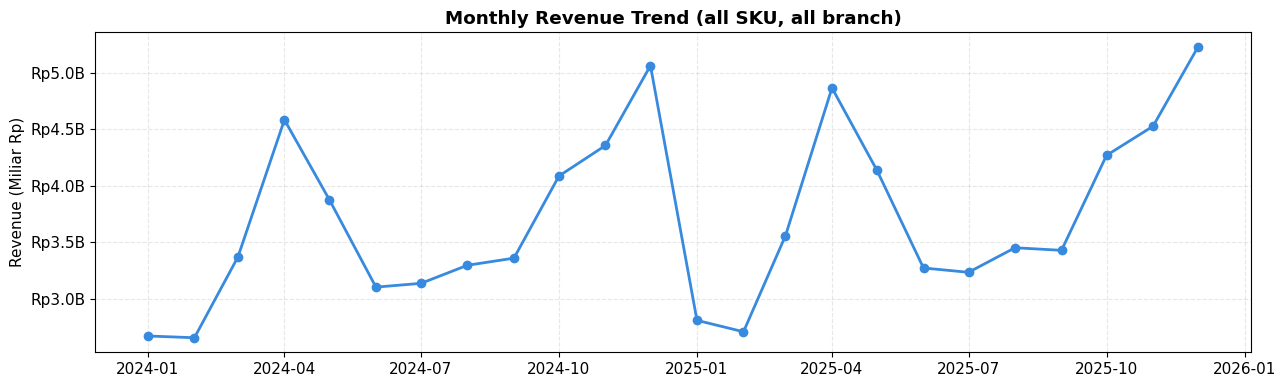

✅ Saved: monthly_trend.png


In [4]:
# Monthly revenue trend
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['Date'], monthly['Revenue']/1e9, marker='o', linewidth=2, color='#378ADD')
ax.set_title('Monthly Revenue Trend (all SKU, all branch)', fontweight='bold')
ax.set_ylabel('Revenue (Miliar Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rp{x:.1f}B'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: monthly_trend.png')


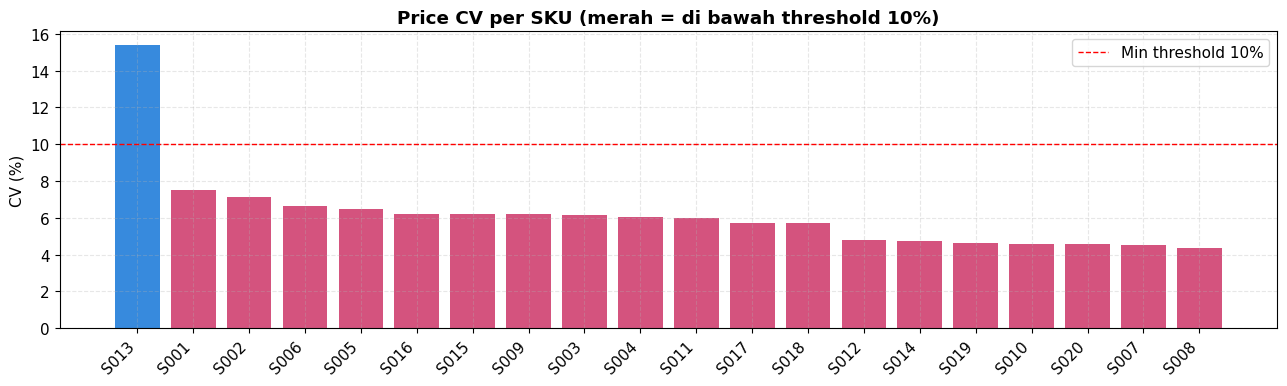

=== Price CV per SKU ===
SKU_ID  cv_pct
  S013   15.37
  S001    7.54
  S002    7.16
  S006    6.67
  S005    6.46
  S016    6.22
  S015    6.20
  S009    6.19
  S003    6.16
  S004    6.03
  S011    6.01
  S017    5.73
  S018    5.73
  S012    4.79
  S014    4.73
  S019    4.61
  S010    4.56
  S020    4.56
  S007    4.55
  S008    4.37


In [5]:
# Price CV per SKU
cv = df.groupby(['SKU_ID'])['DiscountedPrice'].agg(['mean','std'])
cv['cv_pct'] = (cv['std']/cv['mean']*100).round(2)
cv = cv.sort_values('cv_pct', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
colors = [('#D4537E' if v < 10 else '#378ADD') for v in cv['cv_pct']]
ax.bar(cv['SKU_ID'], cv['cv_pct'], color=colors)
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='Min threshold 10%')
ax.set_title('Price CV per SKU (merah = di bawah threshold 10%)', fontweight='bold')
ax.set_ylabel('CV (%)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_price_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Price CV per SKU ===')
print(cv[['SKU_ID','cv_pct']].to_string(index=False))


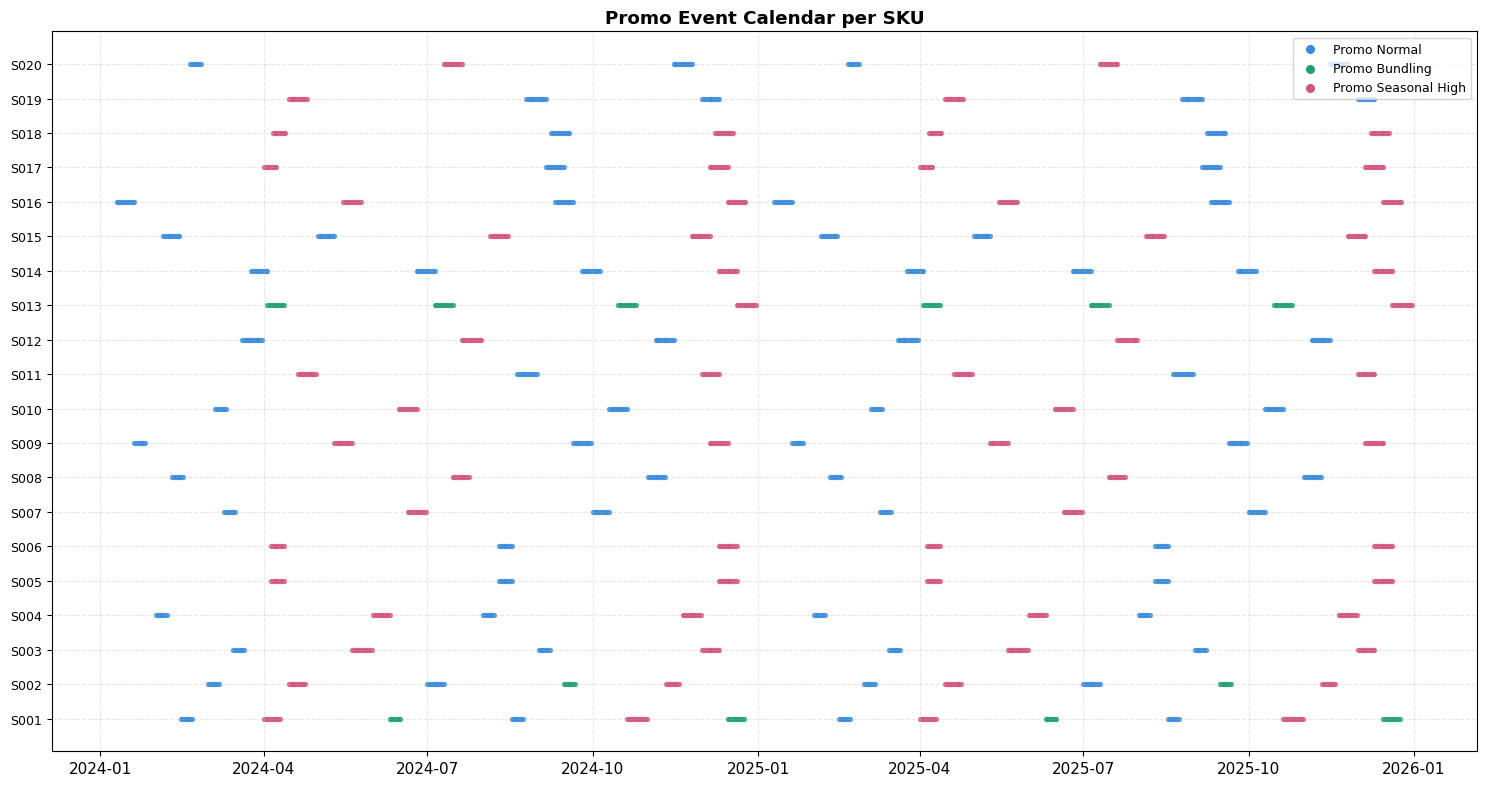

✅ Saved: promo_calendar.png


In [6]:
# Promo event calendar — visualisasi per SKU
promo_df = df[df['IsPromoDay']==1][['Date','SKU_ID','Promo_Category']].drop_duplicates()
skus_sorted = sorted(df['SKU_ID'].unique())

fig, ax = plt.subplots(figsize=(15, 8))
promo_colors = {
    'Promo Normal': '#378ADD', 'Promo Bundling': '#1D9E75', 'Promo Seasonal High': '#D4537E'
}
for i, sku in enumerate(skus_sorted):
    sku_promo = promo_df[promo_df['SKU_ID']==sku]
    for _, row in sku_promo.iterrows():
        color = promo_colors.get(row['Promo_Category'], '#999')
        ax.scatter(row['Date'], i, color=color, s=8, alpha=0.7)

ax.set_yticks(range(len(skus_sorted)))
ax.set_yticklabels(skus_sorted, fontsize=9)
ax.set_title('Promo Event Calendar per SKU', fontweight='bold')
for pt, col in promo_colors.items():
    ax.scatter([], [], color=col, label=pt, s=30)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_promo_calendar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: promo_calendar.png')


In [7]:
df['month_num'] = (df['Year'] - 2024) * 12 + df['Month']
df['log_qty']   = np.log(df['Qty'] + 1)

qty_wide  = df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='log_qty')
disc_wide = df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='DiscountPercentage')
meta_wide = df.groupby(['Date','Branch'])[['month_num','Year']].first()

sku_cat   = df.groupby('SKU_ID')['SKU_Category'].first().to_dict()
sku_brand = df.groupby('SKU_ID')['Brand'].first().to_dict()
sku_name  = df.groupby('SKU_ID')['SKU_Name'].first().to_dict()

print(f'qty_wide shape  : {qty_wide.shape}')
print(f'disc_wide shape : {disc_wide.shape}')
print(f'N obs per branch: {df.groupby("Branch").size().iloc[0] // df["SKU_ID"].nunique()} hari')


qty_wide shape  : (2924, 20)
disc_wide shape : (2924, 20)
N obs per branch: 731 hari


In [8]:
results = []

for cat in sorted(df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2: continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()

            if len(reg_df) < 100: continue

            model = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch) + C(Year)',
                data=reg_df
            ).fit()

            coef = model.params.get('disc_pct_A')
            pval = model.pvalues.get('disc_pct_A')
            if coef is None: continue

            # Diagnostic
            residuals   = model.resid
            _, _, skew, _= jarque_bera(residuals)
            bp          = smd.het_breuschpagan(residuals, model.model.exog)
            cv_a        = (disc_wide[sku_a].std() / disc_wide[sku_a].mean() * 100
                           if disc_wide[sku_a].mean() != 0 else 0)

            norm_flag   = 'PASS' if abs(skew) < 1.0 else f'WARN: skew={skew:.2f}'
            hetero_flag = 'PASS' if bp[1] > 0.01 else f'WARN: p={bp[1]:.3f}'
            cv_flag     = 'PASS' if cv_a >= 10 else f'WARN: CV={cv_a:.1f}%'
            reliability = 'RELIABLE' if all('WARN' not in f for f in [norm_flag, hetero_flag, cv_flag]) else 'UNRELIABLE'

            verdict = ('Tidak Signifikan' if pval >= 0.05
                       else 'CANNIBALIZATION' if coef < 0 else 'KOMPLEMEN')

            results.append({
                'SKU_Category': cat,
                'SKU_A': sku_a, 'SKU_A_Name': sku_name[sku_a], 'Brand_A': sku_brand[sku_a],
                'SKU_B': sku_b, 'SKU_B_Name': sku_name[sku_b], 'Brand_B': sku_brand[sku_b],
                'coef_disc_A': round(coef, 4), 'p_value': round(pval, 4),
                'r_squared': round(model.rsquared, 4), 'n_obs': len(reg_df),
                'cv_disc_A': round(cv_a, 2), 'skew': round(skew, 3),
                'norm_flag': norm_flag, 'hetero_flag': hetero_flag, 'cv_flag': cv_flag,
                'reliability': reliability, 'verdict': verdict,
            })
        except: continue

results_df = pd.DataFrame(results)
reliable   = results_df[results_df['reliability']=='RELIABLE']

print('=== VERDICT SUMMARY (RELIABLE only) ===')
print(reliable['verdict'].value_counts())
print(f'\nTotal pasangan : {len(results_df)}')
print(f'RELIABLE       : {len(reliable)}')
print(f'UNRELIABLE     : {len(results_df) - len(reliable)}')

results_df.to_csv(OUTPUT_DIR + 'cannibalization_results.csv', index=False)
print('\n✅ Saved: cannibalization_results.csv')


=== VERDICT SUMMARY (RELIABLE only) ===
verdict
KOMPLEMEN           24
Tidak Signifikan     5
CANNIBALIZATION      3
Name: count, dtype: int64

Total pasangan : 58
RELIABLE       : 32
UNRELIABLE     : 26

✅ Saved: cannibalization_results.csv


In [9]:
print('=== CANNIBALIZATION (p<0.05, coef negatif) ===')
c = reliable[reliable['verdict']=='CANNIBALIZATION'].sort_values('coef_disc_A')
display(c[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))

print('\n=== KOMPLEMEN (p<0.05, coef positif) ===')
k = reliable[reliable['verdict']=='KOMPLEMEN'].sort_values('coef_disc_A', ascending=False)
display(k[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))


=== CANNIBALIZATION (p<0.05, coef negatif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Biskuit,Nabati Biskuit Rasa Cokelat,Richoco,Nabati Biskuit Rasa Kelapa,Richeese,-0.6774,0.0000,0.8623,2924
1,Extruded Snack,Richoco Ahh! Extruded 15g,Richoco,Richeese Siip Jagung Bakar 20g,Richeese,-0.5125,0.0000,0.8598,2924
2,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco,Richoco Wafer Hazelnut 50g,Richoco,-0.2513,0.0019,0.8503,2924



=== KOMPLEMEN (p<0.05, coef positif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Kue/Pie,Nextar Brownies Pie 40g,Nextar,Nextar Nastar Pie 30g,Nextar,1.1703,0.0000,0.8661,2924
1,Kue/Pie,Nextar Nastar Pie 30g,Nextar,Nextar Brownies Pie 40g,Nextar,1.1118,0.0000,0.8615,2924
2,Extruded Snack,Richeese Siip Jagung Bakar 20g,Richeese,Richoco Ahh! Extruded 15g,Richoco,1.1099,0.0000,0.8533,2924
3,Extruded Snack,Richeese Siip Jagung Bakar 20g,Richeese,Richeese Siip Keju 20g,Richeese,1.0364,0.0000,0.8526,2924
4,Wafer,Richoco Wafer Cokelat 50g,Richoco,Richoco Wafer Cokelat 10g Renceng,Richoco,0.9643,0.0000,0.8588,2924
5,Wafer,Richoco Wafer Cokelat 50g,Richoco,Richeese Wafer Pink Lava 50g,Richeese,0.8916,0.0000,0.8567,2924
6,Wafer,Richoco Wafer Hazelnut 50g,Richoco,Richeese Wafer Keju 50g,Richeese,0.8752,0.0000,0.8522,2924
7,Wafer,Richoco Wafer Cokelat 50g,Richoco,Richoco Wafer Hazelnut 50g,Richoco,0.8573,0.0000,0.8550,2924
8,Wafer,Richeese Wafer Keju 50g,Richeese,Richoco Wafer Cokelat 10g Renceng,Richoco,0.6923,0.0000,0.8562,2924
9,Wafer,Richeese Wafer Keju 50g,Richeese,Richoco Wafer Hazelnut 50g,Richoco,0.6242,0.0000,0.8531,2924


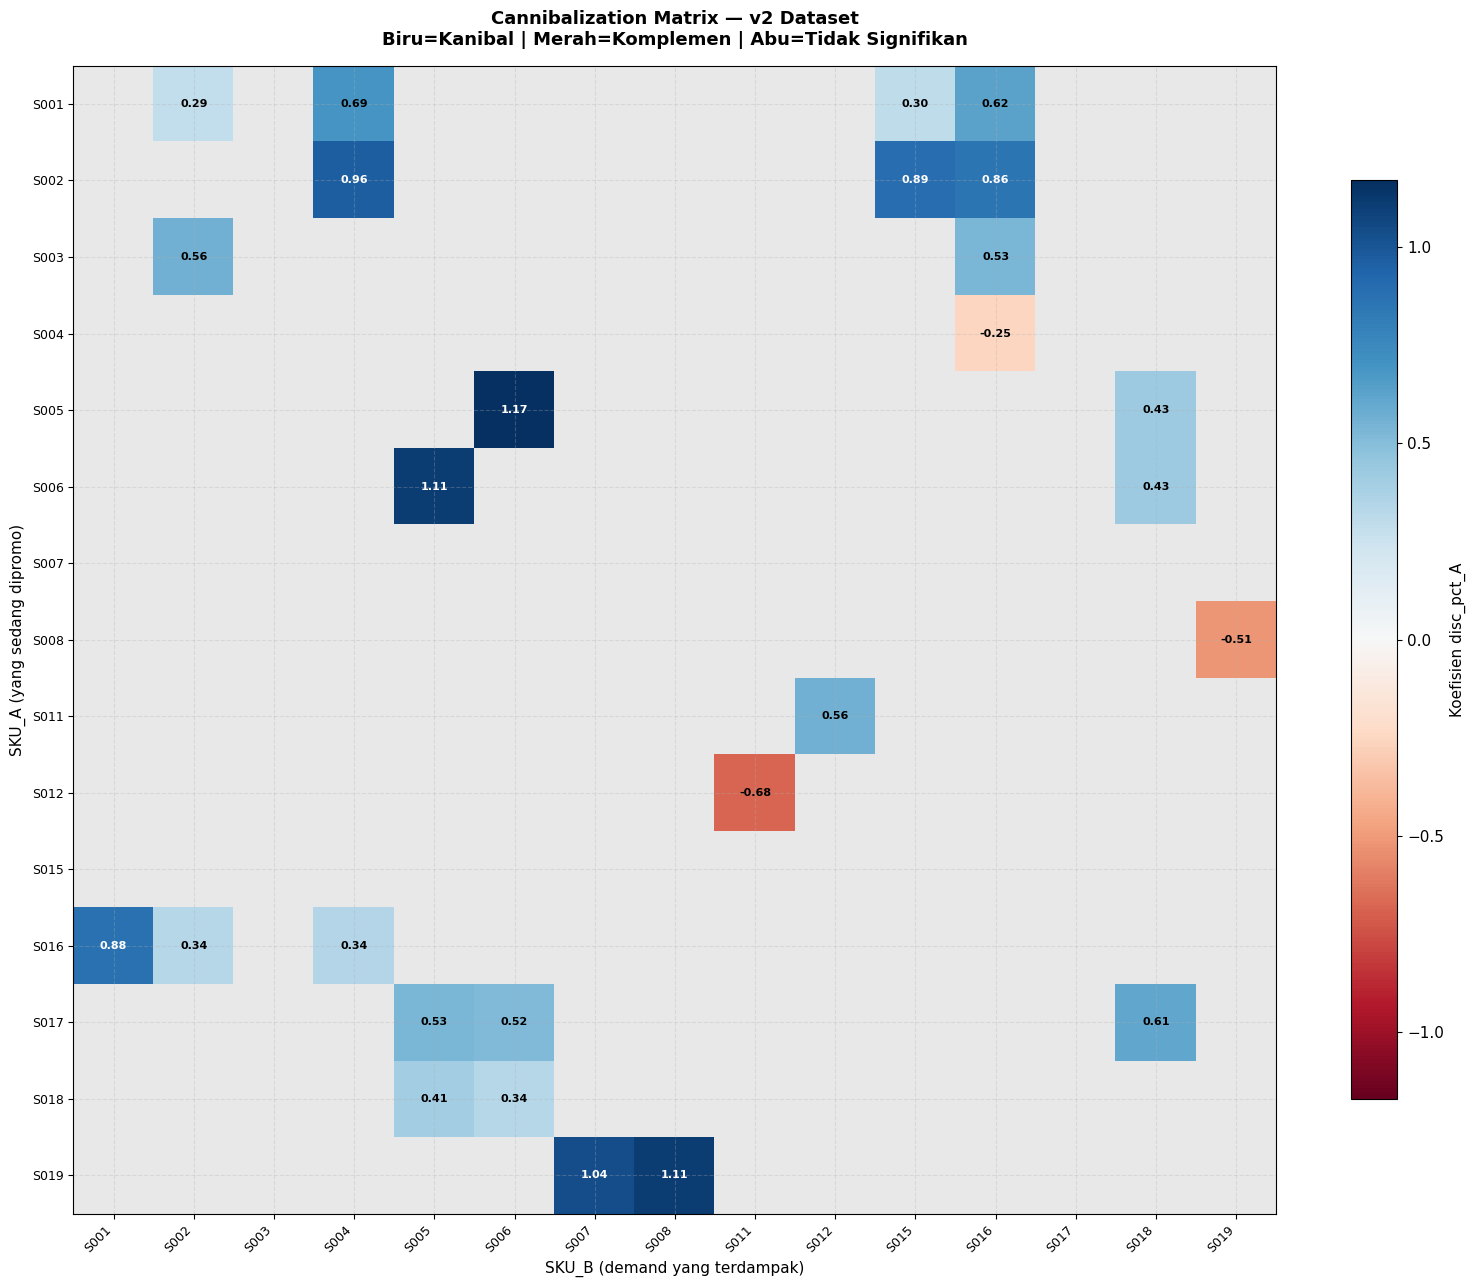

✅ Saved: cannibalization_matrix.png


In [11]:
all_skus = sorted(set(reliable['SKU_A'].unique()) | set(reliable['SKU_B'].unique()))
matrix   = pd.DataFrame(np.nan, index=all_skus, columns=all_skus)

for _, row in reliable.iterrows():
    if row['verdict'] != 'Tidak Signifikan':
        matrix.loc[row['SKU_A'], row['SKU_B']] = row['coef_disc_A']

fig, ax = plt.subplots(figsize=(16, 13))
cmap = plt.cm.RdBu
cmap.set_bad(color='#E8E8E8')
vals        = matrix.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
vmax        = max(abs(finite_vals).max(), 0.5) if len(finite_vals) > 0 else 1.0

im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(all_skus)))
ax.set_yticks(range(len(all_skus)))
ax.set_xticklabels(all_skus, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_skus, fontsize=9)

for i, sa in enumerate(all_skus):
    for j, sb in enumerate(all_skus):
        val = matrix.loc[sa, sb]
        if not np.isnan(val):
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('SKU_B (demand yang terdampak)', fontsize=11)
ax.set_ylabel('SKU_A (yang sedang dipromo)', fontsize=11)
ax.set_title('Cannibalization Matrix — v2 Dataset\nBiru=Kanibal | Merah=Komplemen | Abu=Tidak Signifikan',
             fontsize=13, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='Koefisien disc_pct_A', shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_cannibalization_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: cannibalization_matrix.png')


In [12]:
daily_rev = df.groupby('SKU_ID')['Revenue'].mean().reset_index()
daily_rev.columns = ['SKU_ID','avg_daily_rev']

cannibal_pairs = reliable[reliable['verdict']=='CANNIBALIZATION'].copy()
impact_rows    = []

for _, row in cannibal_pairs.iterrows():
    rev_b      = daily_rev[daily_rev['SKU_ID']==row['SKU_B']]['avg_daily_rev'].values[0]
    pct_change = row['coef_disc_A'] * 0.10
    impact_rows.append({
        'SKU_Category'    : row['SKU_Category'],
        'SKU_A'           : row['SKU_A'], 'SKU_A_Name': row['SKU_A_Name'],
        'SKU_B'           : row['SKU_B'], 'SKU_B_Name': row['SKU_B_Name'],
        'coef_disc_A'     : row['coef_disc_A'],
        'p_value'         : row['p_value'],
        'avg_daily_rev_B' : round(rev_b, 0),
        'pct_qty_change'  : round(pct_change * 100, 2),
        'daily_rev_impact': round(rev_b * pct_change, 0),
    })

impact_df = pd.DataFrame(impact_rows).sort_values('daily_rev_impact')
display(impact_df[['SKU_Category','SKU_A_Name','SKU_B_Name',
                   'pct_qty_change','avg_daily_rev_B','daily_rev_impact']].reset_index(drop=True))

print(f'\nTotal revenue at risk/hari : Rp{abs(impact_df["daily_rev_impact"].sum()):,.0f}')
impact_df.to_csv(OUTPUT_DIR + 'revenue_impact.csv', index=False)
print('✅ Saved: revenue_impact.csv')


,SKU_Category,SKU_A_Name,SKU_B_Name,pct_qty_change,avg_daily_rev_B,daily_rev_impact
0,Biskuit,Nabati Biskuit Rasa Cokelat,Nabati Biskuit Rasa Kelapa,-6.77,1225236.0,-82998.0
1,Extruded Snack,Richoco Ahh! Extruded 15g,Richeese Siip Jagung Bakar 20g,-5.12,737280.0,-37786.0
2,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco Wafer Hazelnut 50g,-2.51,1501606.0,-37735.0



Total revenue at risk/hari : Rp158,519
✅ Saved: revenue_impact.csv


In [14]:
!pip install prophet statsmodels pandas numpy matplotlib

     ---------------------------------------- 0.0/53.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/53.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/53.1 kB ? eta -:--:--
     ---------------------------------------- 53.1/53.1 kB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 4.2 MB/s eta 0:00:03
   - -------------------------------------- 0.3/12.1 MB 4.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/12.1 MB 4.8 MB/s eta 0:00:03
   -- ------------------------------------- 0.9/12.1 MB 4.9 MB/s eta 0:00:03
   --- ------------------------------------ 1.1/12.1 MB 5.0 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/12.1 MB 5.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.7/12.1 MB 5.7 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.1 MB 6.1 MB/s eta 0:00:02
   -------- ------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Agregasi daily qty per SKU (semua branch digabung)
from prophet import Prophet

daily = df.groupby(['Date','SKU_ID','SKU_Name','SKU_Category'])[['Qty','Revenue']].sum().reset_index()

train_end      = pd.Timestamp('2025-09-30')
forecast_start = pd.Timestamp('2025-10-01')
forecast_end   = pd.Timestamp('2025-12-31')

skus             = sorted(daily['SKU_ID'].unique())
forecast_results = []
evaluation       = []

print('Training Prophet models...')
for sku in skus:
    sku_data = daily[daily['SKU_ID']==sku][['Date','Qty','Revenue']].copy()
    sku_name_val = daily[daily['SKU_ID']==sku]['SKU_Name'].iloc[0]
    sku_cat_val  = daily[daily['SKU_ID']==sku]['SKU_Category'].iloc[0]

    train   = sku_data[sku_data['Date'] <= train_end].rename(columns={'Date':'ds','Qty':'y'})
    actuals = sku_data[(sku_data['Date'] >= forecast_start) & (sku_data['Date'] <= forecast_end)]

    if len(train) < 100: continue

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        interval_width=0.95,
    )
    m.fit(train[['ds','y']])

    future   = m.make_future_dataframe(periods=92)
    forecast = m.predict(future)

    fc_period = forecast[forecast['ds'] >= forecast_start][['ds','yhat','yhat_lower','yhat_upper']].copy()
    fc_period['SKU_ID']       = sku
    fc_period['SKU_Name']     = sku_name_val
    fc_period['SKU_Category'] = sku_cat_val

    avg_price = sku_data['Revenue'].sum() / sku_data['Qty'].sum()
    fc_period['qty_forecast']     = fc_period['yhat'].clip(lower=0).round(0).astype(int)
    fc_period['qty_lower']        = fc_period['yhat_lower'].clip(lower=0).round(0).astype(int)
    fc_period['qty_upper']        = fc_period['yhat_upper'].clip(lower=0).round(0).astype(int)
    fc_period['revenue_forecast'] = (fc_period['qty_forecast'] * avg_price).round(0)
    forecast_results.append(fc_period)

    if len(actuals) > 0:
        fc_eval = forecast[forecast['ds'].isin(actuals['Date'])][['ds','yhat']].copy()
        merged  = actuals.rename(columns={'Date':'ds'}).merge(fc_eval, on='ds')
        if len(merged) > 0:
            mape = (abs(merged['Qty'] - merged['yhat']) / merged['Qty']).mean() * 100
            evaluation.append({
                'SKU_ID': sku, 'SKU_Name': sku_name_val,
                'MAPE_pct': round(mape, 2), 'n_days': len(merged),
            })

    print(f'  ✓ {sku} done')

forecast_df = pd.concat(forecast_results, ignore_index=True)
eval_df     = pd.DataFrame(evaluation).sort_values('MAPE_pct')

print(f'\n✅ All models done')


Training Prophet models...


08:58:18 - cmdstanpy - INFO - Chain [1] start processing
08:58:19 - cmdstanpy - INFO - Chain [1] done processing
08:58:20 - cmdstanpy - INFO - Chain [1] start processing
08:58:20 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S001 done


08:58:20 - cmdstanpy - INFO - Chain [1] start processing
08:58:20 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S002 done


...

  ✓ S017 done


08:58:24 - cmdstanpy - INFO - Chain [1] start processing
08:58:24 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S018 done


08:58:25 - cmdstanpy - INFO - Chain [1] start processing
08:58:25 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S019 done
  ✓ S020 done

✅ All models done


In [20]:
print('=== FORECAST EVALUATION (MAPE) ===')
display(eval_df.reset_index(drop=True))
print(f'\nAvg MAPE : {eval_df["MAPE_pct"].mean():.2f}%')
print(f'Min MAPE : {eval_df["MAPE_pct"].min():.2f}% ({eval_df.iloc[0]["SKU_ID"]})')
print(f'Max MAPE : {eval_df["MAPE_pct"].max():.2f}% ({eval_df.iloc[-1]["SKU_ID"]})')

forecast_df.to_csv(OUTPUT_DIR + 'timeseries_forecast.csv', index=False)
eval_df.to_csv(OUTPUT_DIR + 'forecast_evaluation.csv', index=False)
print('\n✅ Saved: timeseries_forecast.csv, forecast_evaluation.csv')


=== FORECAST EVALUATION (MAPE) ===


,SKU_ID,SKU_Name,MAPE_pct,n_days
0,S014,Nabati Drinko Richoco 150ml,8.30,92
1,S005,Nextar Brownies Pie 40g,9.39,92
2,S009,Richeese Mi Instan Keju Pedas,9.83,92
3,S017,Nextar Choco Delight 40g,10.06,92
4,S006,Nextar Nastar Pie 30g,10.17,92
5,S008,Richoco Ahh! Extruded 15g,10.31,92
6,S010,Richeese Mi Instan Ramen Keju,10.31,92
7,S020,Richeese Mi Instan Goreng,10.62,92
8,S019,Richeese Siip Jagung Bakar 20g,10.93,92
9,S002,Richoco Wafer Cokelat 50g,11.22,92



Avg MAPE : 11.38%
Min MAPE : 8.30% (S014)
Max MAPE : 14.60% (S003)

✅ Saved: timeseries_forecast.csv, forecast_evaluation.csv


In [21]:
# Q4 2025 Revenue Forecast Summary
forecast_df['Month'] = pd.to_datetime(forecast_df['ds']).dt.month
q4_monthly = forecast_df.groupby(['SKU_ID','SKU_Name','SKU_Category','Month'])[
    ['qty_forecast','revenue_forecast']].sum().reset_index()
month_map = {10:'Oktober', 11:'November', 12:'Desember'}
q4_monthly['Month_Name'] = q4_monthly['Month'].map(month_map)

q4_summary = q4_monthly.groupby(['SKU_ID','SKU_Name','SKU_Category']).agg(
    qty_q4    = ('qty_forecast','sum'),
    rev_q4    = ('revenue_forecast','sum')
).reset_index().sort_values('rev_q4', ascending=False)

print('=== Q4 2025 REVENUE FORECAST per SKU ===')
q4_display = q4_summary.copy()
q4_display['rev_q4_fmt'] = q4_display['rev_q4'].apply(lambda x: f'Rp{x/1e9:.2f}B')
display(q4_display[['SKU_ID','SKU_Name','SKU_Category','qty_q4','rev_q4_fmt']].reset_index(drop=True))


=== Q4 2025 REVENUE FORECAST per SKU ===


,SKU_ID,SKU_Name,SKU_Category,qty_q4,rev_q4_fmt
0,S001,Richeese Wafer Keju 50g,Wafer,261383,Rp1.51B
1,S004,Richoco Wafer Cokelat 10g Renceng,Wafer,116322,Rp1.14B
2,S003,Richeese Wafer Keju 10g Renceng,Wafer,116116,Rp1.13B
3,S005,Nextar Brownies Pie 40g,Kue/Pie,117055,Rp0.94B
4,S013,Nabati Drinko Richeese 150ml,Minuman,239408,Rp0.88B
5,S006,Nextar Nastar Pie 30g,Kue/Pie,118397,Rp0.84B
6,S017,Nextar Choco Delight 40g,Kue/Pie,115991,Rp0.79B
7,S018,Nextar Pineapple Pie 30g,Kue/Pie,114622,Rp0.78B
8,S016,Richoco Wafer Hazelnut 50g,Wafer,113259,Rp0.66B
9,S002,Richoco Wafer Cokelat 50g,Wafer,111397,Rp0.65B


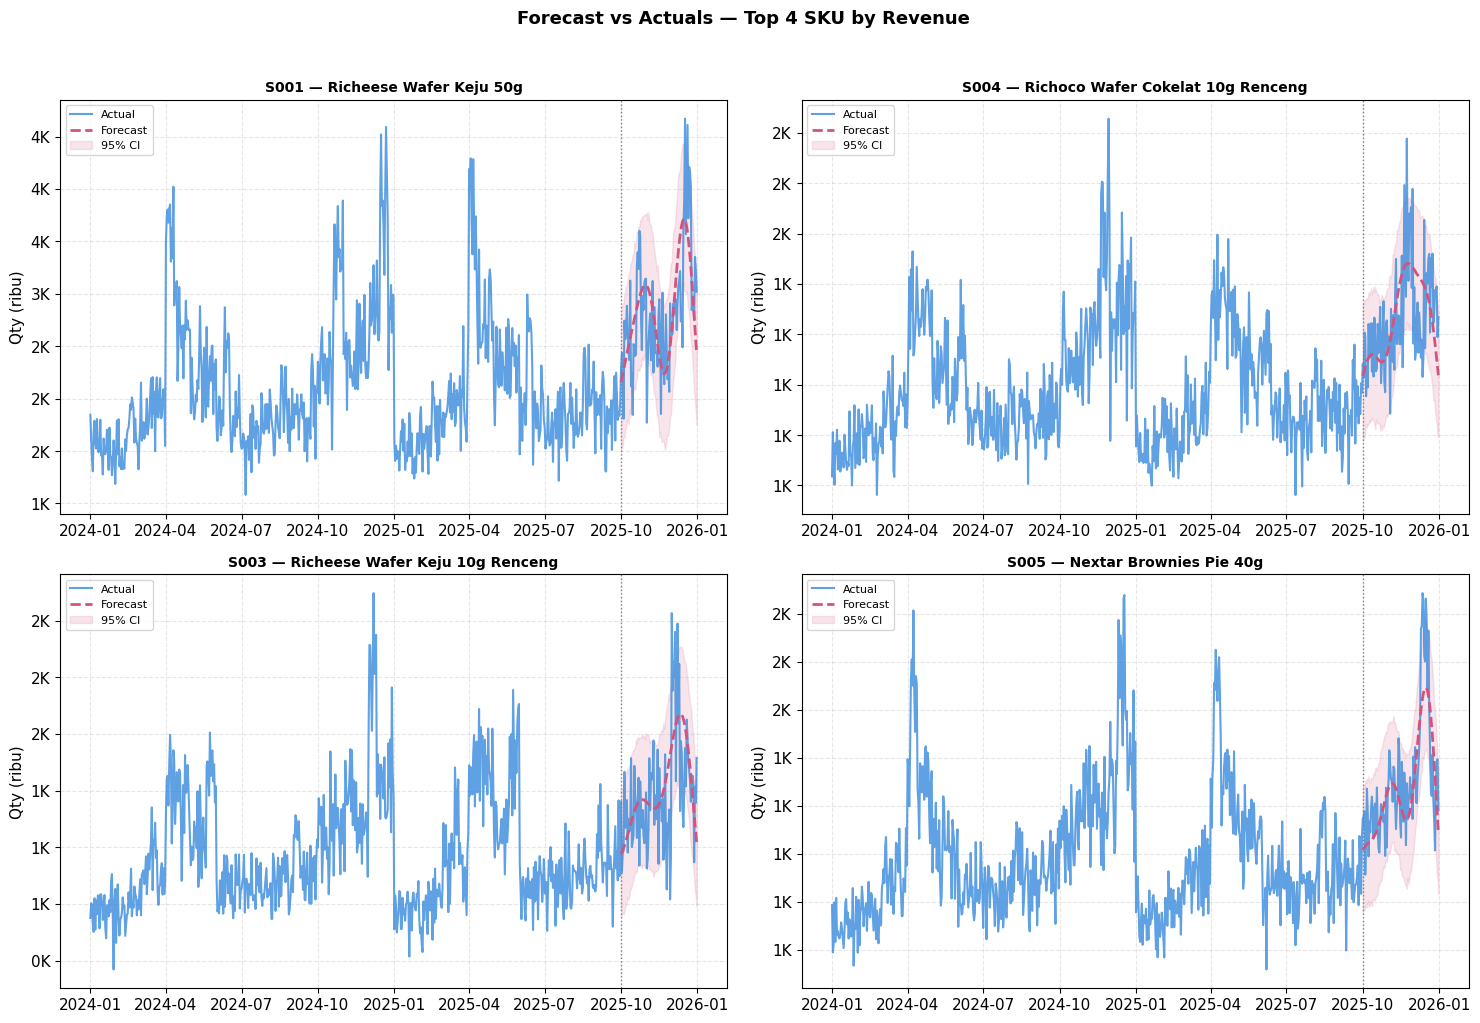

✅ Saved: 05_forecast_vs_actuals.png


In [22]:
# Visualisasi forecast vs actuals untuk top 4 SKU
top4_skus = q4_summary.head(4)['SKU_ID'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, sku in enumerate(top4_skus):
    ax  = axes[idx]
    sku_name_val = daily[daily['SKU_ID']==sku]['SKU_Name'].iloc[0]
    sku_hist     = daily[daily['SKU_ID']==sku][['Date','Qty']].copy()
    sku_fc       = forecast_df[forecast_df['SKU_ID']==sku].copy()
    sku_fc['ds'] = pd.to_datetime(sku_fc['ds'])

    # Historical
    ax.plot(sku_hist['Date'], sku_hist['Qty']/1000, color='#378ADD', linewidth=1.5, label='Actual', alpha=0.8)

    # Forecast
    ax.plot(sku_fc['ds'], sku_fc['qty_forecast']/1000, color='#D4537E', linewidth=2,
            linestyle='--', label='Forecast')
    ax.fill_between(sku_fc['ds'], sku_fc['qty_lower']/1000, sku_fc['qty_upper']/1000,
                    color='#D4537E', alpha=0.15, label='95% CI')

    ax.axvline(pd.Timestamp('2025-10-01'), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{sku} — {sku_name_val}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Qty (ribu)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
    ax.legend(fontsize=8)

plt.suptitle('Forecast vs Actuals — Top 4 SKU by Revenue', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '05_forecast_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_forecast_vs_actuals.png')


In [23]:
print('=' * 65)
print('RINGKASAN HASIL ANALISIS v2')
print('=' * 65)

print(f'\n--- Dataset ---')
print(f'Periode         : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total rows      : {len(df):,}')
print(f'SKU             : {df["SKU_ID"].nunique()}')
print(f'Branch          : {df["Branch"].nunique()}')

print(f'\n--- Cannibalization ---')
print(f'Total pasangan reliable  : {len(reliable)}')
print(f'CANNIBALIZATION detected : {(reliable["verdict"]=="CANNIBALIZATION").sum()}')
print(f'KOMPLEMEN detected       : {(reliable["verdict"]=="KOMPLEMEN").sum()}')
if len(impact_df) > 0:
    print(f'Total revenue at risk    : Rp{abs(impact_df["daily_rev_impact"].sum()):,.0f}/hari')
    print(f'Worst pair               : {impact_df.iloc[0]["SKU_A_Name"]} → {impact_df.iloc[0]["SKU_B_Name"]}')

print(f'\n--- Time Series ---')
print(f'Avg MAPE        : {eval_df["MAPE_pct"].mean():.2f}%')
total_q4_rev = q4_summary["rev_q4"].sum()
print(f'Total Q4 2025   : Rp{total_q4_rev/1e9:.2f}B projected revenue')

print(f'\n--- Output Files ---')
for f in ['cannibalization_results.csv','revenue_impact.csv',
          'timeseries_forecast.csv','forecast_evaluation.csv',
          '01_monthly_trend.png','02_price_cv.png','03_promo_calendar.png',
          '04_cannibalization_matrix.png','05_forecast_vs_actuals.png']:
    print(f'  {OUTPUT_DIR}{f}')

print('\n✅ Analisis selesai')


RINGKASAN HASIL ANALISIS v2

--- Dataset ---
Periode         : 2024-01-01 → 2025-12-31
Total rows      : 58,480
SKU             : 20
Branch          : 4

--- Cannibalization ---
Total pasangan reliable  : 32
CANNIBALIZATION detected : 3
KOMPLEMEN detected       : 24
Total revenue at risk    : Rp158,519/hari
Worst pair               : Nabati Biskuit Rasa Cokelat → Nabati Biskuit Rasa Kelapa

--- Time Series ---
Avg MAPE        : 11.38%
Total Q4 2025   : Rp13.80B projected revenue

--- Output Files ---
  cannibalization_output/cannibalization_results.csv
  cannibalization_output/revenue_impact.csv
  cannibalization_output/timeseries_forecast.csv
  cannibalization_output/forecast_evaluation.csv
  cannibalization_output/01_monthly_trend.png
  cannibalization_output/02_price_cv.png
  cannibalization_output/03_promo_calendar.png
  cannibalization_output/04_cannibalization_matrix.png
  cannibalization_output/05_forecast_vs_actuals.png

✅ Analisis selesai
